In [17]:
import tempfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nexwick_py import parse_nexus_file

from src.utils.ess import compute_ess
from src.utils.tree_ess import compute_tree_ess

In [18]:
sns.set_style("darkgrid")

In [19]:
# the run outputs live in the tests directory at the repository root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tests" / "hcv_emat.xml").exists())
TESTS_PATH = ROOT / "tests"

In [20]:
method_names = ["emat", "beauti"]

# the wall-clock seconds per million MCMC samples of each run, which convert samples into running time
seconds_per_million_samples = {
    "hcv": {"emat": 6.0, "mix": 14.0, "beauti": 15.0, "mix_3": 11.0, "mix_6": 16.0, "mix_10": 10.0,},
    "zika": {"emat": 19.0, "mix": 22.0, "beauti": 328.0},
    "sars": {"emat": 113.0, "beauti": 6300.0},
    "ebola": {"emat": 187.0, "mix": 723},
    "wnv": {"emat": 1560.0, "beauti": 10980},
}

In [21]:
experiment = "wnv"

In [22]:
# likelihood columns are left out, as the EMAT regimes log the augmented likelihood
columns_per_experiment = {
    "hcv": ["posterior", "likelihood", "Tree.height", "Tree.treeLength", "rateAG", "freqParameter.1", "bPopSizes.1", "bGroupSizes.2", "BayesianSkyline"],
    "zika": ["posterior", "likelihood", "Tree.height", "Tree.treeLength", "clockRate", "kappa", "freqParameter.1", "CoalescentExponential", "ePopSize", "growthRate"],
    "sars": ["posterior", "likelihood", "Tree.height", "Tree.treeLength", "clockRate", "kappa", "freqParameter.1", "CoalescentExponential", "ePopSize", "growthRate"],
    "ebola": ["posterior", "likelihood", "Tree.height", "Tree.treeLength", "clockRate", "kappa", "freqParameter.1", "CoalescentExponential", "ePopSize", "growthRate"],
    "wnv": ["posterior", "likelihood", "Tree.height", "Tree.treeLength", "clockRate", "kappa", "freqParameter.1", "CoalescentExponential", "ePopSize", "growthRate"],
}

In [23]:
def get_ess_df(log_df: pd.DataFrame, column: str, method: str, num_points: int = 250):
    ess_dict = {
        "sample": [],
        "minutes": [],
        "ess": [],
        "ess_per_minute": [],
        "column": [],
        "method": [],
    }

    burnin = len(log_df) // 10
    samples = log_df["Sample"].values[burnin:]
    col_values = log_df[column].values[burnin:]

    step = max(1, len(col_values) // num_points)
    seconds_per_sample = seconds_per_million_samples[experiment][method] / 1e6

    for i in range(step, len(col_values) + 1, step):
        # estimate ESS for the first i logged values after burn-in
        try:
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ess_val = compute_ess(col_values[:i])

            ess_dict["sample"].append(samples[i - 1])
            minutes = samples[i - 1] * seconds_per_sample / 60
            ess_dict["minutes"].append(minutes)
            ess_dict["ess"].append(ess_val)
            ess_dict["ess_per_minute"].append(ess_val / minutes)
            ess_dict["column"].append(column)
            ess_dict["method"].append(method)
        except Exception:
            pass

    return pd.DataFrame(ess_dict)

wnv_emat: column CoalescentExponential not logged
wnv_emat: column ePopSize not logged
wnv_emat: column growthRate not logged
wnv_beauti: column CoalescentExponential not logged
wnv_beauti: column ePopSize not logged
wnv_beauti: column growthRate not logged


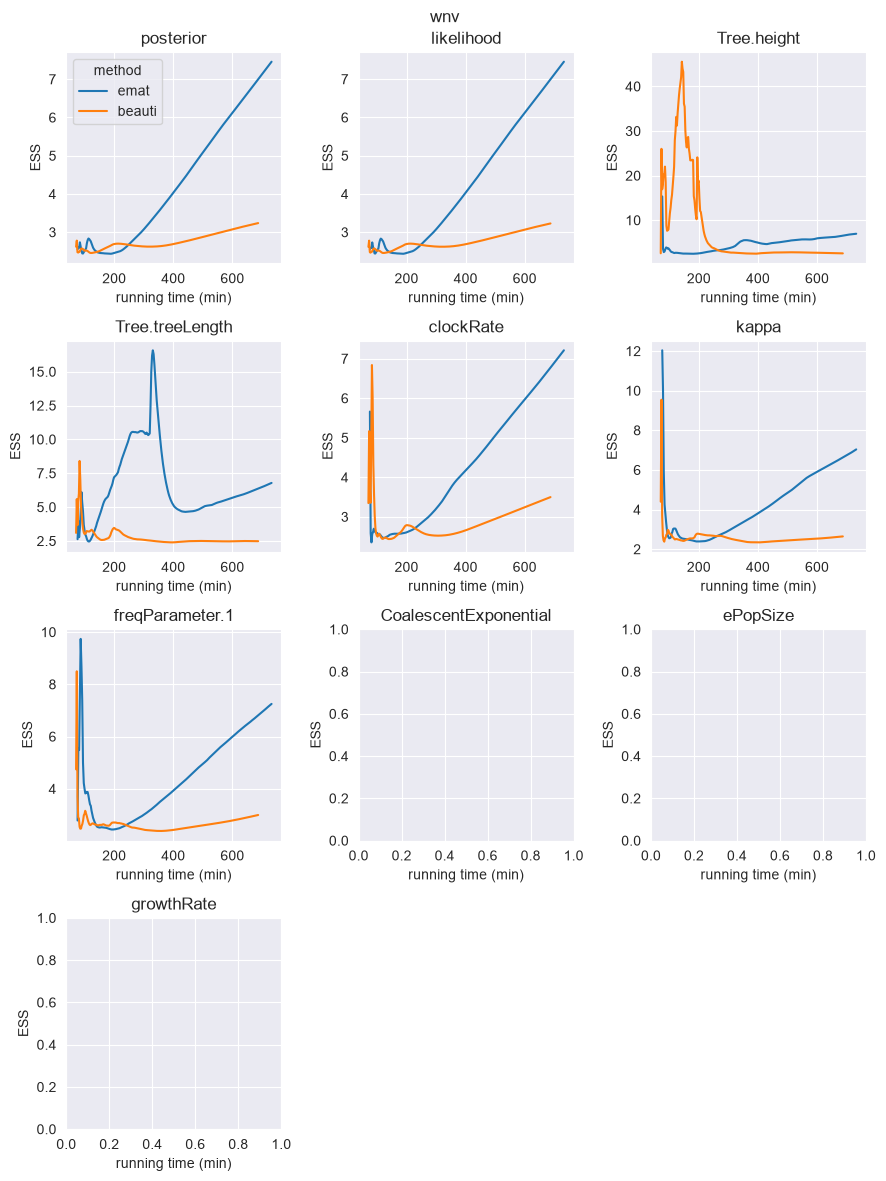

In [24]:
ess_dfs = []

for method in method_names:
    # the log files are named <experiment>_<method>.log or <experiment>_<method>-<seed>.log
    log_paths = sorted(TESTS_PATH.glob(f"{experiment}_{method}.log")) + sorted(TESTS_PATH.glob(f"{experiment}_{method}-*.log"))
    if not log_paths:
        print(f"no log found for {experiment}_{method}")

    log_dfs = [pd.read_csv(path, comment="#", delimiter="\t") for path in log_paths]

    for column in columns_per_experiment[experiment]:
        for log_df in log_dfs:
            if column in log_df.columns:
                ess_dfs.append(get_ess_df(log_df, column, method))
            else:
                print(f"{experiment}_{method}: column {column} not logged")

ess_df = pd.concat(ess_dfs)

columns = columns_per_experiment[experiment]
num_cols = 3
num_rows = (len(columns) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows), squeeze=False)

for ax, column in zip(axes.flat, columns):
    # drop duplicate index labels that may cause seaborn to fail
    data = ess_df[ess_df.column == column].reset_index(drop=True)
    sns.lineplot(data, x="minutes", y="ess", hue="method", hue_order=method_names, ax=ax, legend=ax is axes.flat[0])
    ax.set_title(column)
    ax.set_xlabel("running time (min)")
    ax.set_ylabel("ESS")

for ax in axes.flat[len(columns):]:
    ax.set_visible(False)

fig.suptitle(experiment)
fig.tight_layout()
plt.show()

In [ ]:
# the Fréchet tree ESS is quadratic in the number of trees, so long chains are thinned to at most this many trees
MAX_NUM_TREES = 1000


def read_trees(path: Path):
    """Parse a NEXUS tree file, closing it first if the run is still writing to it."""
    with open(path, "rb") as file:
        file.seek(max(0, path.stat().st_size - 100))
        is_closed = file.read().strip().endswith(b"End;")

    if is_closed:
        return parse_nexus_file(str(path))

    # drop the possibly partially written last tree and close the trees block
    with open(path) as source, tempfile.NamedTemporaryFile("w", suffix=".trees") as closed:
        previous_line = None
        for line in source:
            if previous_line is not None:
                closed.write(previous_line)
            previous_line = line
        closed.write("End;\n")
        closed.flush()
        return parse_nexus_file(closed.name)


tree_ess_dfs = []

for method in method_names:
    # the tree files are named <experiment>_<method>-<alignment>.trees or <experiment>_<method>-<alignment>-<seed>.trees
    tree_paths = sorted(TESTS_PATH.glob(f"{experiment}_{method}-*.trees"))
    if not tree_paths:
        print(f"no trees found for {experiment}_{method}")

    for path in tree_paths:
        trees, _ = read_trees(path)
        trees = trees[len(trees) // 5:]
        trees = trees[::max(1, len(trees) // MAX_NUM_TREES)]

        ess = compute_tree_ess(trees)
        sample = int(trees[-1].name.removeprefix("STATE_"))
        minutes = sample * seconds_per_million_samples[experiment][method] / 1e6 / 60

        tree_ess_dfs.append(pd.DataFrame({
            "sample": [sample],
            "minutes": [minutes],
            "ess": [ess],
            "ess_per_minute": [ess / minutes],
            "column": ["tree topology"],
            "method": [method],
        }))

In [ ]:
pd.DataFrame([df.iloc[-1] for df in tree_ess_dfs if not df.empty])

,sample,minutes,ess,ess_per_minute,column,method
0,350042000,110.846633,31.657538,0.285598,tree topology,emat
0,16112000,88.078933,214.749750,2.438151,tree topology,beauti


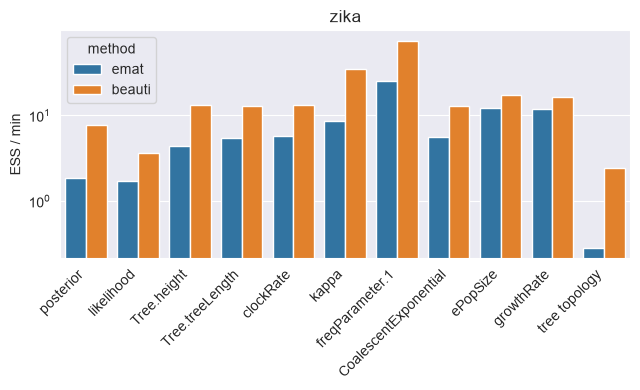

In [ ]:
# the ESS per minute of each run is taken at the end of the run, over the full post-burn-in chain
final_ess_df = pd.DataFrame([df.iloc[-1] for df in ess_dfs + tree_ess_dfs if not df.empty])
bar_columns = columns + ["tree topology"]

fig, ax = plt.subplots(figsize=(0.5 * len(bar_columns) + 1, 4))

sns.barplot(final_ess_df, y="ess_per_minute", x="column", hue="method", order=bar_columns, orient="v", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("ESS / min")
ax.set_xlabel("")
ax.set_title(experiment)
plt.xticks(rotation=45, ha='right')

fig.tight_layout()
plt.show()

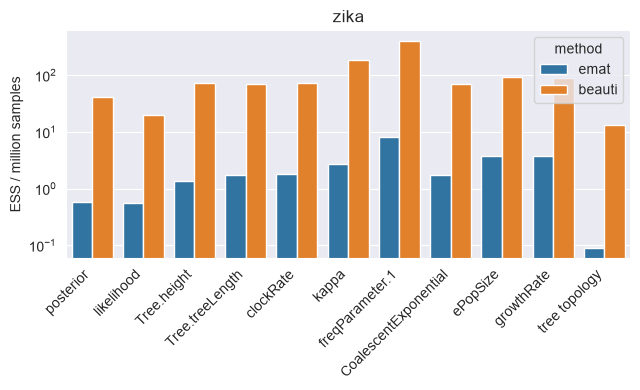

In [ ]:
# the ESS per million MCMC samples, which compares the mixing per step independently of the cost of a step
final_ess_df["ess_per_million_samples"] = final_ess_df["ess"] / final_ess_df["sample"] * 1e6

fig, ax = plt.subplots(figsize=(0.5 * len(bar_columns) + 1, 4))

sns.barplot(final_ess_df, y="ess_per_million_samples", x="column", hue="method", order=bar_columns, orient="v", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("ESS / million samples")
ax.set_xlabel("")
ax.set_title(experiment)
plt.xticks(rotation=45, ha='right')

fig.tight_layout()
plt.show()